# PUDO Complaint Risk — Waymo CPUC Deployment Data (2024 Q3 – 2026 Q2)

Is the frequency of **PUDO (pick-up / drop-off) complaints** for Waymo's driverless
fleet rising or falling once we control for exposure, and where does the hazard sit
on a probability × impact risk chart?

If you have not done so already, run `pudo-build` (if you have not downloaded the zip files) (or `pudo-build --no-download` if you have already downloaded the zip files) to generate `data/parquet/`.

1. **Baseline statistics** — the headline rate and its uncertainty
2. **Distribution over time** — counts vs. exposure vs. rate, with error bars
3. **Trend test** — Poisson / Negative-Binomial GLM under several exposure
   denominators, plus a distribution-free check
4. **Guardrails** — small-n caveats and outlier sensitivity
5. **Risk curve & risk-matrix placement** — a 5×5 heat-map, PUDO placed from the data

The exposure-adjusted rate — not the raw count — is the finding. `PUDOTravelLane`
is redacted at source in every file, so it is never plotted.

# 0. Get Data & Helper Functions

In [7]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

DATA = Path(os.environ.get("PUDO_DATA_DIR", "../data")) / "parquet"

final_data = pl.read_parquet(DATA / "final_pudo_summary.parquet")
summary = pl.read_parquet(DATA / "pudo_summary.parquet")
monthly = pl.read_parquet(DATA / "monthly_activity.parquet")
pudo_counts = pl.read_parquet(DATA / "pudo_counts.parquet")
complaints = pl.read_parquet(DATA / "complaints.parquet")   # ride-level, 2025Q1+ only


# -------------------------------------------------------------------
# Inspect datasets
# -------------------------------------------------------------------

datasets = {
    "final_data": final_data,
    "summary": summary,
    "monthly": monthly,
    "pudo_counts": pudo_counts,
    "complaints": complaints,
}

for name, df in datasets.items():
    print(f"\n{'=' * 80}")
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns ({len(df.columns)}):")

    for col in df.columns:
        print(f"  - {col}")

    print("\nFirst 8 rows:")
    display(df.head(8))


# -------------------------------------------------------------------
# Analysis
# -------------------------------------------------------------------

s = summary.to_pandas().sort_values("period_id").reset_index(drop=True)
s["t"] = np.arange(len(s))


Dataset: final_data
Shape: (8, 3)
Columns (3):
  - period_label
  - trips
  - pudo_complaints

First 8 rows:


period_label,trips,pudo_complaints
str,f64,i64
"""2024 Q3 (Jun-Aug)""",751844.0,41
"""2024 Q4 (Sep-Dec)""",1.852614e6,51
"""2025 Q1""",1.818206e6,27
"""2025 Q2""",2.234912e6,42
"""2025 Q3""",2.676001e6,42
"""2025 Q4""",3.748532e6,66
"""2026 Q1""",3.905934e6,69
"""2026 Q2""",4.220075e6,79



Dataset: summary
Shape: (8, 32)
Columns (32):
  - period_id
  - period_label
  - window_start
  - window_end
  - is_calendar_quarter
  - year
  - quarter
  - company
  - pudo_complaints
  - pudo_collisions
  - all_complaints
  - ride_rows
  - schema
  - pudo_travel_lane
  - vmt_total
  - vmt_p1
  - vmt_p2
  - vmt_p3
  - trips
  - months_with_vmt
  - n_months
  - vmt_p1_p3
  - vmt
  - pudo_per_100k_vmt
  - pudo_per_100k_vmt_p1
  - pudo_per_100k_vmt_p2
  - pudo_per_100k_vmt_p3
  - pudo_per_100k_vmt_p1_p3
  - pudo_per_100k_trips
  - pudo_per_million_rides
  - deadhead_share
  - pudo_share_of_complaints

First 8 rows:


period_id,period_label,window_start,window_end,is_calendar_quarter,year,quarter,company,pudo_complaints,pudo_collisions,all_complaints,ride_rows,schema,pudo_travel_lane,vmt_total,vmt_p1,vmt_p2,vmt_p3,trips,months_with_vmt,n_months,vmt_p1_p3,vmt,pudo_per_100k_vmt,pudo_per_100k_vmt_p1,pudo_per_100k_vmt_p2,pudo_per_100k_vmt_p3,pudo_per_100k_vmt_p1_p3,pudo_per_100k_trips,pudo_per_million_rides,deadhead_share,pudo_share_of_complaints
str,str,date,date,bool,i64,i64,str,i64,i64,i64,i64,str,i64,f64,f64,f64,f64,f64,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2024Q3""","""2024 Q3 (Jun-Aug)""",2024-06-01,2024-08-31,false,2024,3,"""Waymo""",41,11,236,null,"""aggregate""",null,4.3857e6,1.6300e6,647401.87,2.1083e6,751844.0,3,3,3.7383e6,4.3857e6,0.934855,2.515269,6.333006,1.944732,1.096754,5.453259,null,0.371672,0.173729
"""2024Q4""","""2024 Q4 (Sep-Dec)""",2024-09-01,2024-12-31,false,2024,4,"""Waymo""",51,22,524,null,"""aggregate""",null,1.1025e7,3.9660e6,1.5150e6,5544398.8,1.852614e6,4,4,9.5104e6,1.1025e7,0.46257,1.285932,3.366428,0.919847,0.536255,2.752867,null,0.359716,0.097328
"""2025Q1""","""2025 Q1""",2025-01-01,2025-03-31,true,2025,1,"""Waymo""",27,33,270,2631228,"""microdata""",null,1.1234e7,4224179.4,1.3768e6,5.6327e6,1.818206e6,3,3,9.8568e6,1.1234e7,0.24035,0.639177,1.96112,0.479347,0.273922,1.48498,10.261368,0.376031,0.1
"""2025Q2""","""2025 Q2""",2025-04-01,2025-06-30,true,2025,2,"""Waymo""",42,54,248,3151218,"""microdata""",null,1.3688e7,4.2671e6,1.8843e6,7.5363e6,2.234912e6,3,3,1.1803e7,1.3688e7,0.306844,0.984281,2.228897,0.557301,0.35583,1.879269,13.32818,0.311744,0.169355
"""2025Q3""","""2025 Q3""",2025-07-01,2025-09-30,true,2025,3,"""Waymo""",42,46,403,3747947,"""microdata""",null,1.7015e7,4.8924e6,2.5579e6,9565041.3,2.676001e6,3,3,1.4457e7,1.7015e7,0.246836,0.858478,1.64197,0.439099,0.290508,1.569506,11.206135,0.287528,0.104218
"""2025Q4""","""2025 Q4""",2025-10-01,2025-12-31,true,2025,4,"""Waymo""",66,50,486,4496264,"""microdata""",null,2.4736e7,7.6295e6,3.2101e6,1.3897e7,3.748532e6,3,3,2.1526e7,2.4736e7,0.266815,0.865067,2.05602,0.474933,0.306604,1.760689,14.678853,0.308433,0.135802
"""2026Q1""","""2026 Q1""",2026-01-01,2026-03-31,true,2026,1,"""Waymo""",69,69,494,4922696,"""microdata""",null,2.6390e7,7.5988e6,3.7656e6,1.5025e7,3.905934e6,3,3,2.2624e7,2.6390e7,0.261467,0.908036,1.832375,0.45923,0.304986,1.766543,14.01671,0.287948,0.139676
"""2026Q2""","""2026 Q2""",2026-04-01,2026-06-30,true,2026,2,"""Waymo""",79,63,514,4888011,"""microdata""",null,2.8143e7,7.3927e6,4.1709e6,1.6580e7,4.220075e6,3,3,2.3972e7,2.8143e7,0.280706,1.068626,1.894081,0.476486,0.329546,1.872005,16.161993,0.26268,0.153696



Dataset: monthly
Shape: (25, 15)
Columns (15):
  - TCPID
  - TotalTrips
  - TotalVMTPeriod1
  - TotalVMTPeriod2
  - TotalVMTPeriod3
  - TotalVMTZEV
  - TotalPassengersCarried
  - TotalPMT
  - period_id
  - analysis_period
  - company
  - year
  - month
  - quarter
  - vmt_total

First 8 rows:


TCPID,TotalTrips,TotalVMTPeriod1,TotalVMTPeriod2,TotalVMTPeriod3,TotalVMTZEV,TotalPassengersCarried,TotalPMT,period_id,analysis_period,company,year,month,quarter,vmt_total
str,f64,f64,f64,f64,f64,f64,f64,str,str,str,i32,i8,i8,f64
"""PSG0038152""",188847.0,424530.89,169059.05,523809.59,1.1174e6,291644.0,799159.95,"""2024P3_JunAug""","""2024Q3""","""Waymo""",2024,6,2,1.1174e6
"""PSG0038152""",250752.0,546915.07,206038.6,686511.35,1.4395e6,406590.0,1.0949e6,"""2024P3_JunAug""","""2024Q3""","""Waymo""",2024,7,3,1.4395e6
"""PSG0038152""",312245.0,658598.23,272304.22,897938.83,1.8288e6,499170.0,1.3978e6,"""2024P3_JunAug""","""2024Q3""","""Waymo""",2024,8,3,1.8288e6
"""PSG0038152""",354124.0,703066.31,313213.03,1.0495e6,2.0657e6,536341.0,1.5531e6,"""2024P4_SepNov""","""2024Q4""","""Waymo""",2024,9,3,2.0657e6
"""PSG0038152""",453478.0,837887.47,372677.49,1.3549e6,2565470.1,670919.0,1944253.5,"""2024P4_SepNov""","""2024Q4""","""Waymo""",2024,10,4,2.5655e6
"""PSG0038152""",503634.0,1.1639e6,400756.94,1.5039e6,3.0686e6,746677.0,2.1665e6,"""2024P4_SepNov""","""2024Q4""","""Waymo""",2024,11,4,3.0686e6
"""PSG0038152""",541378.0,1.2611e6,428311.59,1.6362e6,3.3256e6,814602.0,2.3621e6,"""2024P5_Dec""","""2024Q4""","""Waymo""",2024,12,4,3.3256e6
"""PSG0038152""",550457.0,1.4305e6,416489.71,1634709.9,3.4817e6,783182.0,2.2319e6,"""2025Q1""","""2025Q1""","""Waymo""",2025,1,1,3.4817e6



Dataset: pudo_counts
Shape: (8, 8)
Columns (8):
  - period_label
  - period_id
  - pudo_complaints
  - pudo_collisions
  - all_complaints
  - ride_rows
  - schema
  - pudo_travel_lane

First 8 rows:


period_label,period_id,pudo_complaints,pudo_collisions,all_complaints,ride_rows,schema,pudo_travel_lane
str,str,i64,i64,i64,i64,str,i64
"""2024 Q3 (Jun-Aug)""","""2024Q3""",41,11,236,null,"""aggregate""",null
"""2024 Q4 (Sep-Dec)""","""2024Q4""",51,22,524,null,"""aggregate""",null
"""2025 Q1""","""2025Q1""",27,33,270,2631228,"""microdata""",null
"""2025 Q2""","""2025Q2""",42,54,248,3151218,"""microdata""",null
"""2025 Q3""","""2025Q3""",42,46,403,3747947,"""microdata""",null
"""2025 Q4""","""2025Q4""",66,50,486,4496264,"""microdata""",null
"""2026 Q1""","""2026Q1""",69,69,494,4922696,"""microdata""",null
"""2026 Q2""","""2026Q2""",79,63,514,4888011,"""microdata""",null



Dataset: complaints
Shape: (23837364, 22)
Columns (22):
  - TCPID
  - CollisionPUDOPassenger
  - CollisionPUDOPedestrian
  - CollisionPUDOBicycleScooter
  - CollisionPUDOMotorcycles
  - CollisionPUDOOtherVehicle
  - CollisionPUDORail
  - CollisionPUDOProperty
  - ComplaintSafety
  - ComplaintPUDO
  - ComplaintAccessibility
  - ComplaintWAV
  - ComplaintCustomerService
  - ComplaintOther
  - period_id
  - raw_period
  - year
  - quarter
  - month
  - company
  - source_file
  - CollisionPUDOAny

First 8 rows:


TCPID,CollisionPUDOPassenger,CollisionPUDOPedestrian,CollisionPUDOBicycleScooter,CollisionPUDOMotorcycles,CollisionPUDOOtherVehicle,CollisionPUDORail,CollisionPUDOProperty,ComplaintSafety,ComplaintPUDO,ComplaintAccessibility,ComplaintWAV,ComplaintCustomerService,ComplaintOther,period_id,raw_period,year,quarter,month,company,source_file,CollisionPUDOAny
str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,i32,i8,i8,str,str,bool
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false
"""PSG0038152""",false,false,false,false,false,false,false,false,false,false,false,false,false,"""2025Q1""","""2025Q1""",2025,1,null,"""Waymo""","""PSG0038152_2025_05_AV_Incident…",false


## Helper Functions 

In [8]:
# --- setup: helpers used throughout -----------------------------------------
# `period_id` is the clean YYYYQn key; `period_label` spells out the real month
# window (2024Q3 = Jun–Aug, 2024Q4 = Sep–Dec are NOT calendar quarters — see
# `is_calendar_quarter`). Wrap the parenthetical so x-tick labels stay compact.
s["label"] = s["period_label"].str.replace(" (", "\n(", regex=False)
labels = s["label"]

# Exposure denominators: name -> (summary count col, summary rate col).
# Trips is the primary measure (matches final_pudo_summary; one trip = one
# pick-up + one drop-off = one PUDO opportunity, no deadhead ambiguity).
# VMT total is kept as the one secondary cross-check -- the P1/P2/P3 phase
# split (deadhead / en route / passenger-carrying) is dropped throughout: it
# is not actually defined anywhere in CPUC's reference key, so vmt_p1 /
# vmt_p3 / vmt_p1_p3 / deadhead_share are excluded from this analysis.
DENOMS = {
    "Trips (1 PU + 1 DO each)": ("trips",     "pudo_per_100k_trips"),
    "VMT total (cross-check)":  ("vmt_total", "pudo_per_100k_vmt"),
}

def poisson_ci(k, exposure, per=1e5, alpha=0.05):
    """Exact (Garwood) Poisson CI on a rate = k / exposure * per.

    Uses the chi-square relationship, so it is valid at any count (including 0)
    and never returns a negative lower bound — unlike the normal / Wald interval.
    """
    k = np.asarray(k, dtype=float)
    exposure = np.asarray(exposure, dtype=float)
    with np.errstate(invalid="ignore"):
        lo = np.where(k > 0, stats.chi2.ppf(alpha / 2, 2 * k) / 2, 0.0)
    hi = stats.chi2.ppf(1 - alpha / 2, 2 * k + 2) / 2
    return lo / exposure * per, hi / exposure * per

# --- asset export: the ONE notebook stays here; it just also drops plain
# files (PNG figures, markdown table/text fragments) into the site's assets
# folder so paper.qmd can pull them in as properly numbered, captioned
# Figure/Table objects instead of raw code output. Re-run this notebook and
# re-render the site; no copying or syncing of the notebook itself required.
ASSETS = Path(os.environ.get("PUDO_ASSETS_DIR", "../../project-site/assets"))
ASSETS.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str, dpi: int = 160) -> None:
    """Save a figure to assets/<name>.png for `![...](assets/<name>.png)` in the paper."""
    fig.savefig(ASSETS / f"{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"[assets] wrote {name}.png")

def _md_table(df: pd.DataFrame) -> str:
    """Minimal Pandoc pipe-table formatter (no extra dependency like tabulate)."""
    cols = [str(c) for c in df.columns]
    rows = [[str(v) for v in row] for row in df.itertuples(index=False)]
    widths = [max(len(c), *(len(r[i]) for r in rows)) if rows else len(c)
              for i, c in enumerate(cols)]
    def fmt_row(vals):
        return "| " + " | ".join(v.ljust(w) for v, w in zip(vals, widths)) + " |"
    sep = "| " + " | ".join("-" * w for w in widths) + " |"
    return "\n".join([fmt_row(cols), sep, *(fmt_row(r) for r in rows)])

def save_table(df: pd.DataFrame, name: str, caption: str) -> None:
    """Save a numbered Pandoc/Quarto table fragment: assets/<name>.md.

    `{{< include assets/<name>.md >}}` inside a `{#<name>}` div in the paper
    renders it as a captioned, cross-referenceable "Table N".
    """
    md = _md_table(df)
    (ASSETS / f"{name}.md").write_text(f"{md}\n\n: {caption} {{#{name}}}\n")
    print(f"[assets] wrote {name}.md")

def save_text(text: str, name: str) -> None:
    """Save a short prose fragment: assets/<name>.md, for `{{< include >}}` inline in a sentence."""
    (ASSETS / f"{name}.md").write_text(text.strip() + "\n")
    print(f"[assets] wrote {name}.md")

In [9]:
# --- Data snapshot: the final, hand-off dataset this whole analysis runs on --
# `final_pudo_summary` = period_label / trips / pudo_complaints, one row per
# analysis quarter (n = 8). Exported as-is (no rates, no modeling) so the
# paper's Data section can show readers exactly what the pipeline hands off.
final_snapshot = final_data.to_pandas().rename(
    columns={"period_label": "period", "trips": "trips", "pudo_complaints": "PUDO complaints"}
)
final_snapshot["trips"] = final_snapshot["trips"].map("{:,.0f}".format)
print(f"final_pudo_summary: {len(final_snapshot)} rows x {len(final_snapshot.columns)} cols\n")
print(final_snapshot.to_string(index=False))

save_table(
    final_snapshot,
    "tbl-final-data",
    "The final hand-off dataset (`final_pudo_summary`): PUDO complaint counts "
    "and trip exposure by analysis quarter, 2024 Q3 - 2026 Q2 (n = 8).",
)

final_pudo_summary: 8 rows x 3 cols

           period     trips  PUDO complaints
2024 Q3 (Jun-Aug)   751,844               41
2024 Q4 (Sep-Dec) 1,852,614               51
          2025 Q1 1,818,206               27
          2025 Q2 2,234,912               42
          2025 Q3 2,676,001               42
          2025 Q4 3,748,532               66
          2026 Q1 3,905,934               69
          2026 Q2 4,220,075               79
[assets] wrote tbl-final-data.md


## 1. Baseline statistics

The data for this analysis will focus on `final_pudo_summary`
(`period_label`, `trips`, `pudo_complaints`). The team's chosen exposure measure
is **trips**: a completed-trip count has no deadhead-mileage ambiguity. VMT is no
longer part of the baseline reporting; it may still show up later as a
robustness cross-check.

Three steps before any trend claim:

**1a — describe the series.** Eight quarters, PUDO complaint counts of 27–79,
over trip volume that grows ~6×. Raw counts are not comparable across quarters,
so everything below is a rate.

**1b — justify the count model.** PUDO complaints are counts of rare events
accumulated over a large number of trips, so **Poisson regression is fit first**
as the natural starting model for exposure-adjusted counts: it lets exposure be
pooled and carried as a `log` offset. We check the defining Poisson assumption
(variance = mean) with the index of dispersion; it fails here, so **section 3
uses Negative Binomial (Poisson with a Gamma-distributed rate) as the primary
trend model**, keeping the Poisson fit only as a diagnostic baseline.

**1c — the numbers.** Per-quarter rate (complaints per 100k trips) with **exact
Poisson 95 % CIs** (χ² method, not the normal / Wald approximation — the same
interval is valid at any count, including the rare-severity rungs in section 5).
These describe uncertainty around each **observed** quarter's count; they are
not the trend model's uncertainty (section 3 reports that separately). Also
shown: the pooled rate, the one baseline number the write-up should quote.


In [10]:
# --- 1a. Descriptive summary statistics --------------------

MILLION = 1_000_000

q = pd.DataFrame({
    "PUDO complaints":  s["pudo_complaints"].astype(float),
    "trips (M)":        s["trips"] / MILLION,
    "rate /100k trips": s["pudo_per_100k_trips"],
})
tbl = (q.describe().T[["mean", "std", "min", "50%", "max"]]
       .rename(columns={"50%": "median"}))
tbl["range"] = q.max() - q.min()
tbl["CV"]    = q.std() / q.mean()
print(f"Per-quarter distribution (n = {len(s)} quarters)\n")

# Summary stats
print(tbl.round(3).to_string())  

k, tr = int(s["pudo_complaints"].sum()), s["trips"].sum()
print(f"\nPooled: {k} PUDO complaints over {tr / 1e6:.1f}M trips.")
print(f"Complaints per quarter range {int(s['pudo_complaints'].min())}-"
      f"{int(s['pudo_complaints'].max())} (median {s['pudo_complaints'].median():.0f}); "
      f"trip volume grows {s['trips'].max() / s['trips'].min():.1f}x across the window,")
print("so raw counts are not comparable between quarters -- every figure below is a rate.")

save_table(
    tbl.round(3).reset_index().rename(columns={"index": "variable"}),
    "tbl-summary-stats",
    "Per-quarter descriptive statistics for PUDO complaints, trips, and the "
    "PUDO-per-100k-trips rate, 2024 Q3 - 2026 Q2 (n = 8).",
)

Per-quarter distribution (n = 8 quarters)

                    mean     std     min  median     max   range     CV
PUDO complaints   52.125  17.570  27.000  46.500  79.000  52.000  0.337
trips (M)          2.651   1.216   0.752   2.455   4.220   3.468  0.459
rate /100k trips   2.317   1.324   1.485   1.819   5.453   3.968  0.572

Pooled: 417 PUDO complaints over 21.2M trips.
Complaints per quarter range 27-79 (median 46); trip volume grows 5.6x across the window,
so raw counts are not comparable between quarters -- every figure below is a rate.
[assets] wrote tbl-summary-stats.md


In [11]:
# --- 1b. Is a Poisson count model appropriate? -----------------------------
# PUDO complaints are counts of rare events over a large, varying number of
# trips -> Poisson regression is fit FIRST as the natural starting model (it
# lets exposure be pooled and carried as a log-offset). Check its defining
# assumption, variance == mean, with the index of dispersion.
counts = s["pudo_complaints"].to_numpy().astype(float)
n = len(counts)
mean_c, var_c = counts.mean(), counts.var(ddof=1) # divide by \(n-1\) → sample variance. delta degrees of freedom for the sample variance. This is the unbiased estimator of the population variance.
vmr = var_c / mean_c                       # index of dispersion (Fano factor); = 1 under Poisson
D   = (n - 1) * vmr                        # dispersion statistic ~ chi2_{n-1} under H0: Poisson

# Is our observed VMR so large that it would be unlikely if the counts were truly Poisson?
p_disp = stats.chi2.sf(D, n - 1)

print(f"PUDO complaint counts: mean {mean_c:.1f}, variance {var_c:.1f}")
print(f"  variance-to-mean ratio (VMR)     {vmr:.2f}      (1.0 under a pure Poisson process)")
print(f"  dispersion test  D = (n-1)*VMR = {D:.1f}   ~ chi2_{n - 1}    p = {p_disp:.4f}")
print(f"  -> {'OVERDISPERSED' if p_disp < 0.05 else 'consistent with Poisson'}: the counts "
      f"scatter ~{vmr:.0f}x more than a pure Poisson process allows.")
print()
print("Reading: the extra spread is mostly REAL rate variation between quarters")
print("(the 2024 launch ramp), not a broken model. So Poisson regression is fit only")
print("as an initial diagnostic baseline in section 3; because VMR >> 1, the PRIMARY")
print("trend model there is Negative Binomial (Poisson + Gamma-distributed rate).")
print("Rate CIs on OBSERVED quarters use the EXACT Poisson (chi-square) interval, not")
print("the normal/Wald one -- it is valid at any count and never goes negative, which")
print("matters for the rare-severity rungs in section 5 (n = 10 and n = 0). That exact")
print("interval describes uncertainty around each observed count, not the trend --")
print("Negative-Binomial regression (section 3) is used for inference about the trend.")

# Wald vs. exact on the smallest quarter, to show the difference is real
i = int(np.argmin(counts)); ki = int(counts[i]); ei = float(s["trips"].iloc[i])
ri = ki / ei * 1e5
half = 1.96 * np.sqrt(ki) / ei * 1e5
elo, ehi = poisson_ci(ki, ei)
print(f"\n{s['period_id'].iloc[i]} (k = {ki}):  rate {ri:.2f} / 100k trips")
print(f"   Wald  95% CI  [{ri - half:.2f}, {ri + half:.2f}]   (symmetric)")
print(f"   exact 95% CI  [{elo:.2f}, {ehi:.2f}]   (skewed toward the upper bound; used here)")


PUDO complaint counts: mean 52.1, variance 308.7
  variance-to-mean ratio (VMR)     5.92      (1.0 under a pure Poisson process)
  dispersion test  D = (n-1)*VMR = 41.5   ~ chi2_7    p = 0.0000
  -> OVERDISPERSED: the counts scatter ~6x more than a pure Poisson process allows.

Reading: the extra spread is mostly REAL rate variation between quarters
(the 2024 launch ramp), not a broken model. So Poisson regression is fit only
as an initial diagnostic baseline in section 3; because VMR >> 1, the PRIMARY
trend model there is Negative Binomial (Poisson + Gamma-distributed rate).
Rate CIs on OBSERVED quarters use the EXACT Poisson (chi-square) interval, not
the normal/Wald one -- it is valid at any count and never goes negative, which
matters for the rare-severity rungs in section 5 (n = 10 and n = 0). That exact
interval describes uncertainty around each observed count, not the trend --
Negative-Binomial regression (section 3) is used for inference about the trend.

2025Q1 (k = 27):  rate

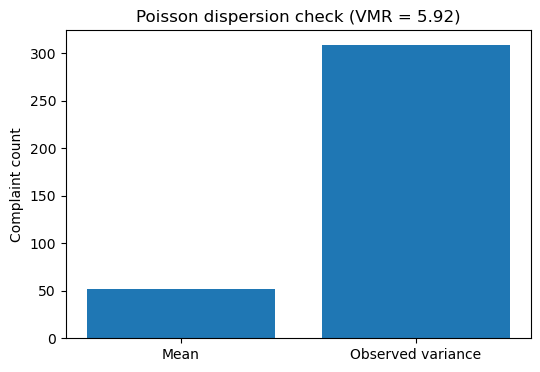

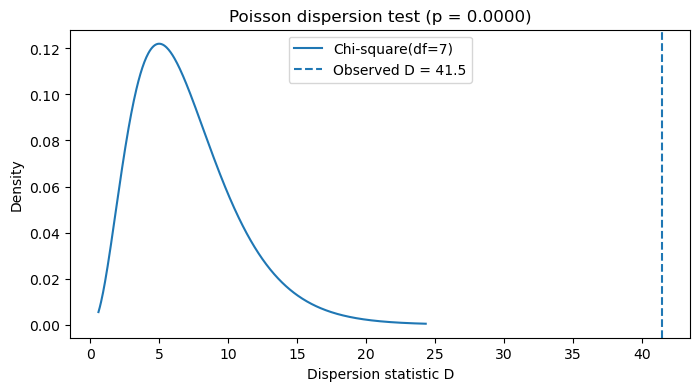

In [12]:
# --- Visualize Poisson dispersion ------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["Mean", "Observed variance"],
    [mean_c, var_c]
)

ax.set_ylabel("Complaint count")
ax.set_title(f"Poisson dispersion check (VMR = {vmr:.2f})")

plt.show()

# --- Visualize dispersion test --------------------------------------------

df = n - 1

x = np.linspace(
    stats.chi2.ppf(0.001, df),
    stats.chi2.ppf(0.999, df),
    500
)

y = stats.chi2.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y, label=f"Chi-square(df={df})")
ax.axvline(
    D,
    linestyle="--",
    label=f"Observed D = {D:.1f}"
)

ax.set_xlabel("Dispersion statistic D")
ax.set_ylabel("Density")
ax.set_title(f"Poisson dispersion test (p = {p_disp:.4f})")
ax.legend()

plt.show()

In [13]:
# --- 1c. per-quarter rates with exact Poisson 95% CIs (trips) --------------
lo_t, hi_t = poisson_ci(s["pudo_complaints"], s["trips"])

baseline = pd.DataFrame({
    "period": s["period_id"],
    "complaints": s["pudo_complaints"],
    "trips (M)": (s["trips"] / 1e6).round(2),
    "per 100k trips (95% CI)": [f"{r:.3f}  [{l:.3f}, {h:.3f}]"
                                for r, l, h in zip(s["pudo_per_100k_trips"], lo_t, hi_t)],
})
baseline

,period,complaints,trips (M),per 100k trips (95% CI)
0,2024Q3,41,0.75,"5.453 [3.913, 7.398]"
1,2024Q4,51,1.85,"2.753 [2.050, 3.620]"
2,2025Q1,27,1.82,"1.485 [0.979, 2.161]"
3,2025Q2,42,2.23,"1.879 [1.354, 2.540]"
4,2025Q3,42,2.68,"1.570 [1.131, 2.122]"
5,2025Q4,66,3.75,"1.761 [1.362, 2.240]"
6,2026Q1,69,3.91,"1.767 [1.374, 2.236]"
7,2026Q2,79,4.22,"1.872 [1.482, 2.333]"


In [14]:
# pooled baseline rate — THE headline number (trips only)
tot_k = int(s["pudo_complaints"].sum())
tot_tr = float(s["trips"].sum())
rate = tot_k / tot_tr * 1e5
lo, hi = poisson_ci(tot_k, tot_tr)
print(f"Pooled 2024Q3–2026Q2:  {tot_k} PUDO complaints / {tot_tr/1e6:,.1f}M trips"
      f"  =  {rate:.3f} per 100k trips   (exact Poisson 95% CI [{lo:.3f}, {hi:.3f}])")
print(f"\n>>> Over the study window Waymo averaged {rate:.2f} PUDO complaints per "
      f"100,000 trips (95% CI {lo:.2f}–{hi:.2f}).")

save_table(
    pd.DataFrame([{"complaints": tot_k, "trips (M)": round(tot_tr / 1e6, 1),
                   "rate per 100k trips": round(rate, 3), "95% CI": f"[{lo:.3f}, {hi:.3f}]"}]),
    "tbl-baseline",
    f"Pooled PUDO complaint rate over the study window ({tot_k} complaints, "
    "2024 Q3 - 2026 Q2).",
)
save_text(
    f"Over the study window Waymo averaged **{rate:.2f}** PUDO complaints per "
    f"100,000 trips (exact Poisson 95% CI {lo:.2f}-{hi:.2f}), from {tot_k} "
    f"complaints over {tot_tr / 1e6:.1f}M trips.",
    "baseline-headline",
)

Pooled 2024Q3–2026Q2:  417 PUDO complaints / 21.2M trips  =  1.966 per 100k trips   (exact Poisson 95% CI [1.782, 2.164])

>>> Over the study window Waymo averaged 1.97 PUDO complaints per 100,000 trips (95% CI 1.78–2.16).
[assets] wrote tbl-baseline.md
[assets] wrote baseline-headline.md


period_id  pudo_complaints  all_complaints  PUDO share
   2024Q3               41             236        17.4
   2024Q4               51             524         9.7
   2025Q1               27             270        10.0
   2025Q2               42             248        16.9
   2025Q3               42             403        10.4
   2025Q4               66             486        13.6
   2026Q1               69             494        14.0
   2026Q2               79             514        15.4

PUDO averages 13% of all reported complaints (range 10%–17%). Safety and 'Other' are the large categories; PUDO is the largest *location/behaviour* category.
[assets] wrote fig-pudo-share.png


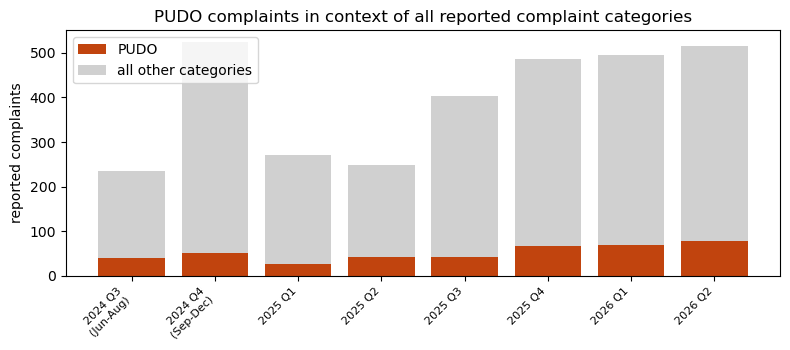

[assets] wrote pudo-share-headline.md


In [15]:
# PUDO as a share of ALL reported complaint categories, per period
mix = summary.select(
    "period_id", "pudo_complaints", "all_complaints", "pudo_share_of_complaints"
).to_pandas()
mix["other_complaints"] = mix["all_complaints"] - mix["pudo_complaints"]
print(mix.assign(**{"PUDO share": (mix["pudo_share_of_complaints"] * 100).round(1)})
        [["period_id", "pudo_complaints", "all_complaints", "PUDO share"]]
        .to_string(index=False))
print(f"\nPUDO averages {mix['pudo_share_of_complaints'].mean():.0%} of all reported "
      f"complaints (range {mix['pudo_share_of_complaints'].min():.0%}–"
      f"{mix['pudo_share_of_complaints'].max():.0%}). Safety and 'Other' are the "
      f"large categories; PUDO is the largest *location/behaviour* category.")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(s["t"], mix["pudo_complaints"], label="PUDO", color="#c1440e")
ax.bar(s["t"], mix["other_complaints"], bottom=mix["pudo_complaints"],
       label="all other categories", color="#d0d0d0")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("reported complaints")
ax.set_title("PUDO complaints in context of all reported complaint categories")
ax.legend()
plt.tight_layout()
save_fig(fig, "fig-pudo-share")
plt.show()

save_text(
    f"PUDO complaints average **{mix['pudo_share_of_complaints'].mean():.0%}** of all "
    f"reported complaint categories over the window (range "
    f"{mix['pudo_share_of_complaints'].min():.0%}-"
    f"{mix['pudo_share_of_complaints'].max():.0%}), making PUDO the largest "
    "location/behaviour complaint category (Safety and 'Other' are larger overall "
    "categories, but are not location-specific).",
    "pudo-share-headline",
)


## 2. Distribution over time

Raw complaint counts rise because the fleet grew ~6×. Every rate panel below is
exposure-adjusted using **trips**; error bars / ribbons are the exact Poisson
CIs from section 1. VMT total is carried alongside as a cross-check (section 3
shows the trend direction is the same under it).

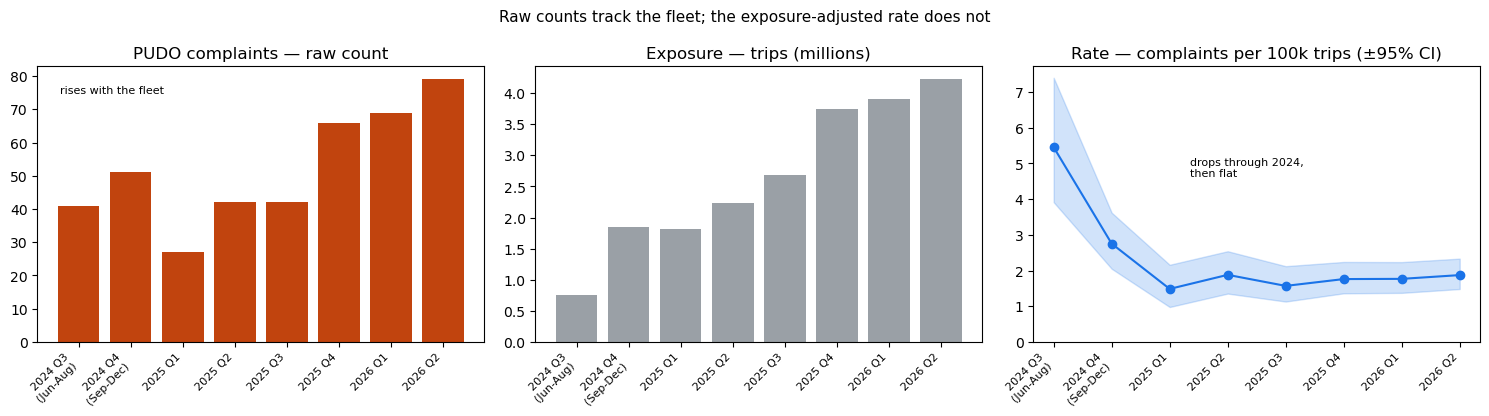

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].bar(s["t"], s["pudo_complaints"], color="#c1440e")
ax[0].set_title("PUDO complaints — raw count")
ax[0].annotate("rises with the fleet", xy=(0.05, 0.9), xycoords="axes fraction", fontsize=8)

ax[1].bar(s["t"], s["trips"] / 1e6, color="#9aa0a6")
ax[1].set_title("Exposure — trips (millions)")

lo, hi = poisson_ci(s["pudo_complaints"], s["trips"])
ax[2].plot(s["t"], s["pudo_per_100k_trips"], marker="o", color="#1a73e8")
ax[2].fill_between(s["t"], lo, hi, alpha=0.2, color="#1a73e8")
ax[2].set_title("Rate — complaints per 100k trips (±95% CI)")
ax[2].set_ylim(0)
ax[2].annotate("drops through 2024,\nthen flat", xy=(0.35, 0.6),
               xycoords="axes fraction", fontsize=8)

for a in ax:
    a.set_xticks(s["t"]); a.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
fig.suptitle("Raw counts track the fleet; the exposure-adjusted rate does not",
             fontsize=11)
plt.tight_layout(); plt.show()

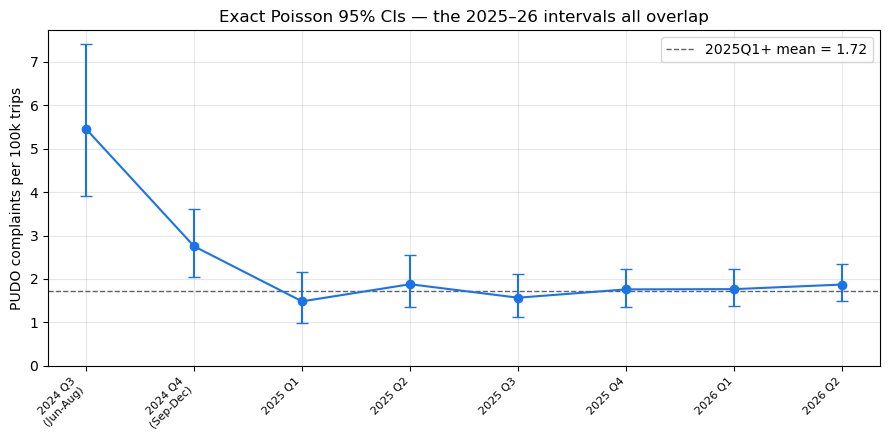

In [17]:
# rate with exact Poisson error bars — with ~8 points, CI overlap is the story
lo, hi = poisson_ci(s["pudo_complaints"], s["trips"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(s["t"], s["pudo_per_100k_trips"],
            yerr=[s["pudo_per_100k_trips"] - lo, hi - s["pudo_per_100k_trips"]],
            marker="o", capsize=4, color="#1a73e8")
ax.axhline(s["pudo_per_100k_trips"].iloc[2:].mean(), color="#5f6368", ls="--", lw=1,
           label=f"2025Q1+ mean = {s['pudo_per_100k_trips'].iloc[2:].mean():.2f}")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("PUDO complaints per 100k trips"); ax.set_ylim(0)
ax.set_title("Exact Poisson 95% CIs — the 2025–26 intervals all overlap")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

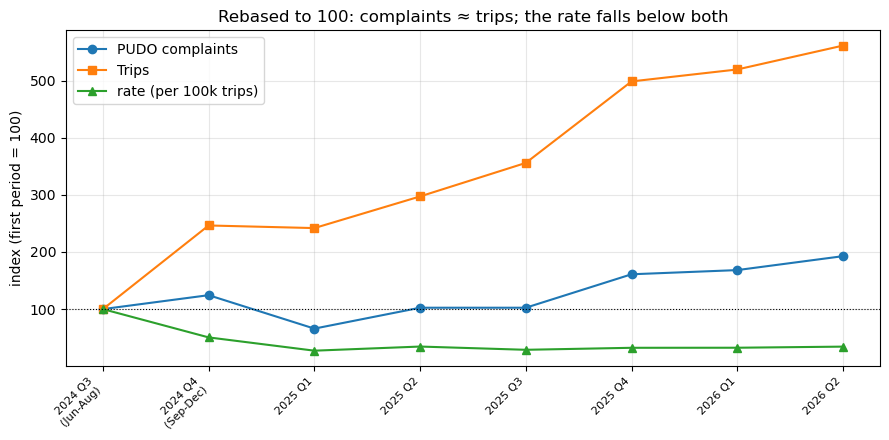

In [18]:
# indexed to 100 at the first period: counts vs trips vs rate
fig, ax = plt.subplots(figsize=(9, 4.5))
for col, lab, style in [("pudo_complaints", "PUDO complaints", "-o"),
                        ("trips", "Trips", "-s"),
                        ("pudo_per_100k_trips", "rate (per 100k trips)", "-^")]:
    v = s[col].to_numpy(dtype=float)
    ax.plot(s["t"], v / v[0] * 100, style, label=lab)
ax.axhline(100, color="k", lw=0.8, ls=":")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("index (first period = 100)")
ax.set_title("Rebased to 100: complaints ≈ trips; the rate falls below both")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

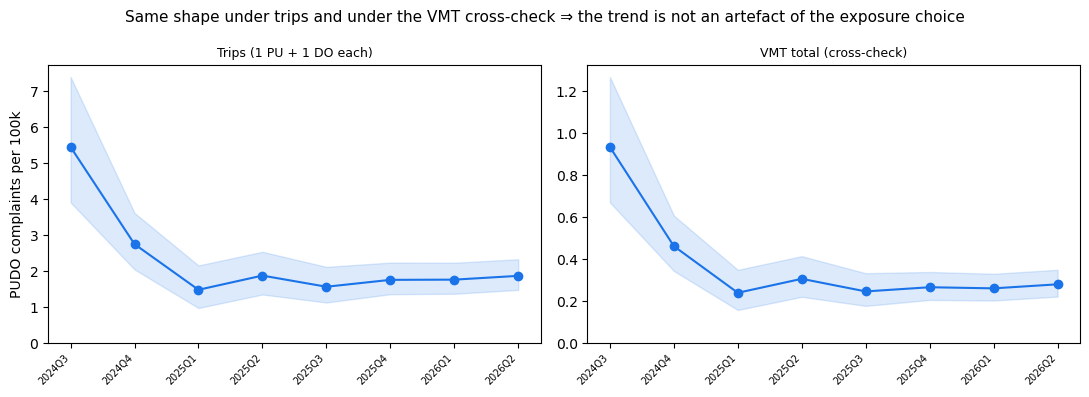

In [19]:
# rate under trips vs. the VMT cross-check, side by side
fig, axes = plt.subplots(1, len(DENOMS), figsize=(5.5 * len(DENOMS), 4))
for axi, (name, (col, rate_col)) in zip(axes, DENOMS.items()):
    r = s[rate_col].to_numpy(dtype=float)
    lo, hi = poisson_ci(s["pudo_complaints"], s[col])
    axi.plot(s["t"], r, marker="o", color="#1a73e8")
    axi.fill_between(s["t"], lo, hi, alpha=0.15, color="#1a73e8")
    axi.set_title(name, fontsize=9)
    axi.set_ylim(0)
    axi.set_xticks(s["t"])
    axi.set_xticklabels(s["period_id"], rotation=45, ha="right", fontsize=7)
axes[0].set_ylabel("PUDO complaints per 100k")
fig.suptitle("Same shape under trips and under the VMT cross-check ⇒ the trend "
             "is not an artefact of the exposure choice", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Trend test

**Poisson is fit first, but only as a diagnostic baseline.** `complaints ~ t`
with `offset = log(exposure)` is the natural starting model for exposure-adjusted
counts, but 1b's index-of-dispersion test found VMR ≈ 5.9 (D ≈ 41.5 vs.
χ²₇, p < 0.001) — the counts are strongly overdispersed relative to Poisson.
**The primary trend model is therefore Negative Binomial** (same log-linear
mean structure, `alpha` estimated by MLE), fit on **trips** exposure. We then:

- run a launch-period **sensitivity analysis** comparing the full study window
  against a post-ramp window that excludes both 2024 quarters, to check
  whether the fitted decline is a launch artifact rather than an ongoing trend;
- refit the same NB model under the VMT-total cross-check from section 2 and
  add a distribution-free Mann-Kendall (Kendall τ vs. time) check — both
  **robustness checks**, not alternative primary models;
- run a leave-one-out scan for single-period sensitivity; and
- refit the whole model as a **Bayesian Negative-Binomial posterior**
  (PyMC/NUTS). With only 8 quarters, the frequentist NB's Wald CI treats the
  MLE dispersion estimate as known, which understates uncertainty; a full
  posterior instead propagates uncertainty in both the regression and
  dispersion parameters, and gives a direct **P(the rate is declining)**
  instead of relying entirely on a large-sample p-value.


In [20]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

d0 = s.dropna(subset=["pudo_complaints", "trips"]).reset_index(drop=True)
if len(d0) < 4:
    raise ValueError(
        f"Only {len(d0)} periods have exposure; need >=4 for a trend fit. "
        "Re-run `pudo-build --no-download` and check its warnings."
    )

def _prep(df_, exposure_col):
    dd = df_.dropna(subset=["pudo_complaints", exposure_col]).reset_index(drop=True)
    return dd.assign(y=dd["pudo_complaints"].astype(float),
                      tt=np.arange(len(dd)),
                      off=np.log(dd[exposure_col].astype(float)))

def _summarize(m, dd, model_name, disp):
    """Common summary dict for a fitted GLM/NB `complaints ~ t` model.

    `ci` / `per_period` are on the RATE-CHANGE scale (exp(.) - 1); `ci_log` is
    the raw log-scale CI on beta_t; `irr` = exp(beta_t) is the incidence rate
    ratio per quarter.
    """
    b, se = m.params["tt"], m.bse["tt"]
    lo, hi = m.conf_int().loc["tt"]
    irr = np.exp(b)
    n = len(dd)
    return dict(model=model_name, dispersion=disp, res=m, data=dd, n=n,
                beta=b, se=se, ci_log=(lo, hi), irr=irr, irr_ci=(np.exp(lo), np.exp(hi)),
                per_period=irr - 1, ci=(np.exp(lo) - 1, np.exp(hi) - 1),
                p=float(m.pvalues["tt"]), total=np.exp(b * (n - 1)) - 1)

def fit_poisson(df_, exposure_col):
    """Diagnostic-only Poisson GLM -- NOT the primary trend model (see 1b)."""
    dd = _prep(df_, exposure_col)
    m = sm.GLM(dd["y"], sm.add_constant(dd["tt"]),
               family=sm.families.Poisson(), offset=dd["off"]).fit()
    disp = m.pearson_chi2 / m.df_resid
    return _summarize(m, dd, "Poisson (diagnostic)", disp)

def fit_nb(df_, exposure_col):
    """Primary trend model: Negative-Binomial GLM, `complaints ~ t`,
    `offset = log(exposure)`, log link, alpha by MLE."""
    dd = _prep(df_, exposure_col)
    pois_ref = sm.GLM(dd["y"], sm.add_constant(dd["tt"]),
                       family=sm.families.Poisson(), offset=dd["off"]).fit()
    disp = pois_ref.pearson_chi2 / pois_ref.df_resid   # reported for reference only
    # method="lbfgs": the default Newton solver is occasionally unstable on
    # small n (esp. the n=6 post-ramp sensitivity subset below) -- silently
    # "converges" to a degenerate Hessian with a huge/undefined SE. lbfgs (and
    # nm) reproduce the identical estimate on the full n=8 fit but converge
    # reliably on the smaller subset too.
    m = smf.negativebinomial("y ~ tt", data=dd, offset=dd["off"].values).fit(
        disp=0, method="lbfgs", maxiter=1000)
    return _summarize(m, dd, "Neg. binomial", disp)

# --- Diagnostic baseline: Poisson (do NOT read this CI/p as the trend result) --
poisson_diag = fit_poisson(d0, "trips")
print("Diagnostic Poisson fit (baseline only -- NOT the primary trend model)")
print(f"  beta_t (log rate/quarter) = {poisson_diag['beta']:.4f}   SE = {poisson_diag['se']:.4f}")
print(f"  IRR = exp(beta_t)         = {poisson_diag['irr']:.4f}   ({poisson_diag['per_period']:+.1%}/qtr)")
print(f"  p-value                   = {poisson_diag['p']:.4f}")
print(f"  Pearson chi2/df           = {poisson_diag['dispersion']:.2f}  "
      "(>>1 -> overdispersed; this CI/p understates uncertainty, see 1b)")

# --- PRIMARY trend model: Negative Binomial ------------------------------------
primary = fit_nb(d0, "trips")
print("\nPRIMARY trend model: Negative-Binomial regression, trips exposure")
print(f"  complaints ~ t, offset = log(trips), n = {primary['n']} quarters")
print(f"  coefficient (beta_t)      = {primary['beta']:.4f}")
print(f"  standard error            = {primary['se']:.4f}")
print(f"  95% CI (log scale)        = [{primary['ci_log'][0]:.4f}, {primary['ci_log'][1]:.4f}]")
print(f"  incidence rate ratio      = exp(beta_t) = {primary['irr']:.4f}   "
      f"(95% CI [{primary['irr_ci'][0]:.4f}, {primary['irr_ci'][1]:.4f}])")
print(f"  % change per quarter      = {primary['per_period']:+.1%}   "
      f"(95% CI {primary['ci'][0]:+.1%} to {primary['ci'][1]:+.1%})")
print(f"  p-value                   = {primary['p']:.4f}")
print(f"  total change over window  = {primary['total']:+.0%}  (2024Q3 -> 2026Q2)")
print(f"\nPlain language: each additional quarter multiplies the expected PUDO "
      f"complaint rate per trip by {primary['irr']:.3f} on average -- a "
      f"{primary['per_period']:+.1%} change per quarter, holding exposure fixed. "
      f"(The Poisson diagnostic above is not used for inference: it assumes "
      "variance = mean, which the counts violate.)")

save_table(
    pd.DataFrame([{
        "term": "t (quarter index)",
        "beta_t": round(primary["beta"], 4),
        "SE": round(primary["se"], 4),
        "95% CI (log)": f"[{primary['ci_log'][0]:.4f}, {primary['ci_log'][1]:.4f}]",
        "IRR = exp(beta_t)": round(primary["irr"], 4),
        "% change / qtr": f"{primary['per_period']:+.1%}",
        "95% CI (% / qtr)": f"[{primary['ci'][0]:+.1%}, {primary['ci'][1]:+.1%}]",
        "p-value": round(primary["p"], 4),
    }]),
    "tbl-nb-primary",
    "Primary Negative-Binomial trend model (pudo_complaints ~ t, "
    "offset = log(trips)): coefficient, standard error, confidence interval, "
    "incidence rate ratio, and percent change per quarter.",
)
save_text(
    f"The primary trend model is Negative-Binomial regression "
    f"(`pudo_complaints ~ t`, `offset = log(trips)`): "
    f"beta_t = {primary['beta']:.3f} (SE {primary['se']:.3f}, 95% CI "
    f"[{primary['ci_log'][0]:.3f}, {primary['ci_log'][1]:.3f}]), an incidence "
    f"rate ratio of {primary['irr']:.3f} per quarter -- a "
    f"**{primary['per_period']:+.1%}** change in the PUDO complaint rate per "
    f"quarter (95% CI {primary['ci'][0]:+.1%} to {primary['ci'][1]:+.1%}, "
    f"p = {primary['p']:.3f}; total change {primary['total']:+.0%} across the "
    "window).",
    "trend-primary-headline",
)


Diagnostic Poisson fit (baseline only -- NOT the primary trend model)
  beta_t (log rate/quarter) = -0.0883   SE = 0.0228
  IRR = exp(beta_t)         = 0.9155   (-8.4%/qtr)
  p-value                   = 0.0001
  Pearson chi2/df           = 5.15  (>>1 -> overdispersed; this CI/p understates uncertainty, see 1b)

PRIMARY trend model: Negative-Binomial regression, trips exposure
  complaints ~ t, offset = log(trips), n = 8 quarters
  coefficient (beta_t)      = -0.1137
  standard error            = 0.0419
  95% CI (log scale)        = [-0.1958, -0.0315]
  incidence rate ratio      = exp(beta_t) = 0.8926   (95% CI [0.8222, 0.9690])
  % change per quarter      = -10.7%   (95% CI -17.8% to -3.1%)
  p-value                   = 0.0067
  total change over window  = -55%  (2024Q3 -> 2026Q2)

Plain language: each additional quarter multiplies the expected PUDO complaint rate per trip by 0.893 on average -- a -10.7% change per quarter, holding exposure fixed. (The Poisson diagnostic above is not u

[assets] wrote fig-trend-fit.png


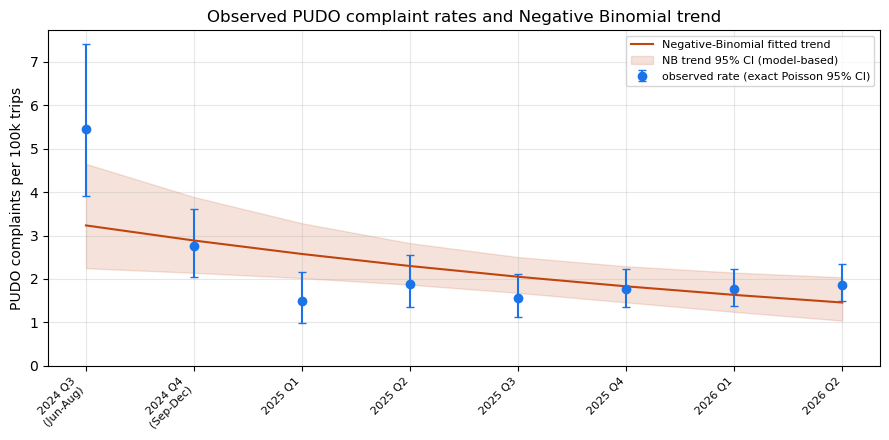

In [21]:
# overlay the fitted NB trend + 95% ribbon on the observed points (delta method
# on the linear predictor). Observed points use the exact Poisson CI from
# section 1 (uncertainty around each OBSERVED count); the ribbon is the NB
# regression's model-based uncertainty about the TREND -- a different quantity,
# not to be read as "the CIs overlap so there's no trend."
res, dd = primary["res"], primary["data"]
ic = "const" if "const" in res.params.index else "Intercept"
cov = res.cov_params()
tt = dd["tt"].to_numpy()
lp = res.params[ic] + res.params["tt"] * tt + dd["off"].to_numpy()
se = np.sqrt(cov.loc[ic, ic] + tt**2 * cov.loc["tt", "tt"] + 2 * tt * cov.loc[ic, "tt"])
denom = dd["trips"].to_numpy() / 1e5
fit_rate, fit_lo, fit_hi = np.exp(lp) / denom, np.exp(lp - 1.96*se) / denom, np.exp(lp + 1.96*se) / denom

obs = dd["y"].to_numpy() / denom
olo, ohi = poisson_ci(dd["y"], dd["trips"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(tt, obs, yerr=[obs - olo, ohi - obs], fmt="o", capsize=3,
            color="#1a73e8", label="observed rate (exact Poisson 95% CI)")
ax.plot(tt, fit_rate, color="#c1440e", label="Negative-Binomial fitted trend")
ax.fill_between(tt, fit_lo, fit_hi, color="#c1440e", alpha=0.15,
                 label="NB trend 95% CI (model-based)")
ax.set_xticks(tt); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("PUDO complaints per 100k trips"); ax.set_ylim(0)
ax.set_title("Observed PUDO complaint rates and Negative Binomial trend")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "fig-trend-fit")
plt.show()


In [22]:
# --- 3a. Launch-period sensitivity: is the decline driven by the 2024 ramp? ---
# 2024Q3 and 2024Q4 look like a deployment/launch ramp (much higher
# exposure-adjusted rate than 2025Q1 onward -- see 1c/section 2). Rather than
# just dropping one quarter, fit the SAME primary NB rate model
# (complaints ~ t, offset = log(trips)) on two pre-registered windows:
#   A. Full period   2024Q3-2026Q2  (n=8; the primary model above)
#   B. Post-ramp     2025Q1-2026Q2  (n=6; excludes both 2024 quarters)
# This is a sensitivity analysis, not a decision to discard 2024 data.
s_post_ramp = s[s["period_id"] >= "2025Q1"].reset_index(drop=True)

window_full = primary                      # re-use the already-fit primary model
window_post = fit_nb(s_post_ramp, "trips")

print("Launch-period sensitivity -- Negative-Binomial trend, full vs. post-ramp")
print(f"{'window':<30s}{'n':>3s}{'beta_t':>9s}{'SE':>8s}{'%/qtr':>10s}"
      f"{'95% CI':>20s}{'p':>8s}")
for label, r in [("A. Full (2024Q3-2026Q2)", window_full),
                  ("B. Post-ramp (2025Q1-2026Q2)", window_post)]:
    print(f"{label:<30s}{r['n']:>3d}{r['beta']:>9.3f}{r['se']:>8.3f}"
          f"{r['per_period']:>+9.1%}   [{r['ci'][0]:+.1%}, {r['ci'][1]:+.1%}]"
          f"{r['p']:>8.3f}")

launch_sens = pd.DataFrame([
    {"window": "A. Full (2024Q3-2026Q2)", "n": window_full["n"],
     "beta_t": round(window_full["beta"], 3), "SE": round(window_full["se"], 3),
     "% / qtr": f"{window_full['per_period']:+.1%}",
     "95% CI": f"[{window_full['ci'][0]:+.1%}, {window_full['ci'][1]:+.1%}]",
     "p-value": round(window_full["p"], 3),
     "total change": f"{window_full['total']:+.0%}"},
    {"window": "B. Post-ramp (2025Q1-2026Q2)", "n": window_post["n"],
     "beta_t": round(window_post["beta"], 3), "SE": round(window_post["se"], 3),
     "% / qtr": f"{window_post['per_period']:+.1%}",
     "95% CI": f"[{window_post['ci'][0]:+.1%}, {window_post['ci'][1]:+.1%}]",
     "p-value": round(window_post["p"], 3),
     "total change": f"{window_post['total']:+.0%}"},
])
print()
print(launch_sens.to_string(index=False))

# Interpretation is derived from the actual fitted numbers, not asserted.
post_negative = window_post["per_period"] < 0
post_significant = window_post["p"] < 0.05
full_significant_decline = window_full["per_period"] < 0 and window_full["p"] < 0.05

if full_significant_decline and not post_significant:
    interpretation = (
        "The apparent decline over the full study period appears to be driven "
        "substantially by the elevated rates observed during the 2024 launch "
        "period: once those two quarters are excluded, the remaining six "
        "quarters show a much weaker, no-longer-significant trend. Rates from "
        "2025 onward appear comparatively stable. This is consistent with a "
        "launch/ramp-period effect rather than a continuing decline, though it "
        "does not establish causation."
    )
elif full_significant_decline and post_negative and post_significant:
    interpretation = (
        "The decline persists even after excluding the 2024 launch-period "
        "quarters, so it is not solely a launch-ramp artifact -- the post-ramp "
        "window still shows a statistically significant decline on its own."
    )
else:
    interpretation = (
        "The post-ramp window's trend direction and/or significance differ "
        "materially from the full-period fit; the full-period trend estimate "
        "should be read with appropriate caution given the small sample."
    )
print(f"\nReading: {interpretation}")

save_table(launch_sens, "tbl-launch-sensitivity",
           "Negative-Binomial trend sensitivity: full study period vs. the "
           "post-ramp window excluding both 2024 launch-period quarters.")
save_text(
    f"Restricting the primary Negative-Binomial model to the post-ramp window "
    f"(2025 Q1 - 2026 Q2, n = {window_post['n']}) gives a slope of "
    f"**{window_post['per_period']:+.1%}** per quarter (95% CI "
    f"{window_post['ci'][0]:+.1%} to {window_post['ci'][1]:+.1%}, "
    f"p = {window_post['p']:.3f}), versus **{window_full['per_period']:+.1%}** "
    f"per quarter (p = {window_full['p']:.3f}) over the full study period. "
    f"{interpretation}",
    "launch-sensitivity-headline",
)


Launch-period sensitivity -- Negative-Binomial trend, full vs. post-ramp
window                          n   beta_t      SE     %/qtr              95% CI       p
A. Full (2024Q3-2026Q2)         8   -0.114   0.042   -10.7%   [-17.8%, -3.1%]   0.007
B. Post-ramp (2025Q1-2026Q2)    6    0.029   0.035    +2.9%   [-3.8%, +10.2%]   0.402

                      window  n  beta_t    SE % / qtr          95% CI  p-value total change
     A. Full (2024Q3-2026Q2)  8  -0.114 0.042  -10.7% [-17.8%, -3.1%]    0.007         -55%
B. Post-ramp (2025Q1-2026Q2)  6   0.029 0.035   +2.9% [-3.8%, +10.2%]    0.402         +16%

Reading: The apparent decline over the full study period appears to be driven substantially by the elevated rates observed during the 2024 launch period: once those two quarters are excluded, the remaining six quarters show a much weaker, no-longer-significant trend. Rates from 2025 onward appear comparatively stable. This is consistent with a launch/ramp-period effect rather than a co

In [23]:
# --- Robustness checks: NB refit under every denominator + Mann-Kendall -------
# Both cross-checks below support the primary NB trend model above; neither
# replaces it. `fit_nb` (not `fit_trend`) is used throughout so every
# denominator gets the SAME primary model family.
results = {name: fit_nb(s, col) for name, (col, _rate) in DENOMS.items()}

rows = []
for name, (col, rate_col) in DENOMS.items():
    r = results[name]
    tau, p_mk = stats.kendalltau(np.arange(len(s)), s[rate_col].to_numpy())
    rows.append({
        "denominator": name.split(" (")[0],
        "model": r["model"],
        "beta_t": round(r["beta"], 3),
        "SE": round(r["se"], 3),
        "%/qtr": f"{r['per_period']:+.1%}",
        "95% CI": f"[{r['ci'][0]:+.0%}, {r['ci'][1]:+.0%}]",
        "p (NB)": f"{r['p']:.3f}",
        "total": f"{r['total']:+.0%}",
        "MK tau": f"{tau:+.2f}",
        "p (MK)": f"{p_mk:.3f}",
    })
trend_table = pd.DataFrame(rows)
print(trend_table.to_string(index=False))

per_q = [results[n]["per_period"] for n in DENOMS]
nb_p = [results[n]["p"] for n in DENOMS]
mk = [stats.kendalltau(np.arange(len(s)), s[c].to_numpy()) for _c, c in DENOMS.values()]
mk_tau = [t for t, _p in mk]
mk_p = [p for _t, p in mk]
print(f"\nNB slope negative under all {len(DENOMS)} denominators: "
      f"{'YES' if max(per_q) < 0 else 'NO'} "
      f"({min(per_q):+.0%} to {max(per_q):+.0%} per quarter; NB p {min(nb_p):.3f}-{max(nb_p):.3f}).")
print(f"Mann-Kendall (distribution-free robustness check) tau negative under both too "
      f"({min(mk_tau):+.2f} to {max(mk_tau):+.2f}), but weaker "
      f"(p {min(mk_p):.2f}-{max(mk_p):.2f}): the rate series is non-monotone "
      f"(dips at 2025Q1, then wobbles) -- the 'fell then flat' pattern, not a steady "
      "slide. This does not prove the trend is absent; it means the monotone-rank "
      "test has limited power on a non-monotone, n=8 series.")

save_table(trend_table, "tbl-trend",
           "Primary Negative-Binomial trend fit and Mann-Kendall robustness check "
           "under every exposure denominator.")
save_text(
    f"The primary Negative-Binomial trend is negative under all {len(DENOMS)} "
    f"exposure denominators tested (per-quarter change {min(per_q):+.0%} to "
    f"{max(per_q):+.0%}; NB p {min(nb_p):.3f}-{max(nb_p):.3f}). Mann-Kendall's tau, "
    "a distribution-free robustness check, is negative under both denominators as "
    f"well, though only marginally significant (p {min(mk_p):.2f}-{max(mk_p):.2f}) "
    "given the non-monotone, fell-then-flat shape of the series.",
    "trend-headline",
)


denominator         model  beta_t    SE  %/qtr      95% CI p (NB) total MK tau p (MK)
      Trips Neg. binomial  -0.114 0.042 -10.7% [-18%, -3%]  0.007  -55%  -0.21  0.548
  VMT total Neg. binomial  -0.135 0.042 -12.7% [-20%, -5%]  0.001  -61%  -0.29  0.399

NB slope negative under all 2 denominators: YES (-13% to -11% per quarter; NB p 0.001-0.007).
Mann-Kendall (distribution-free robustness check) tau negative under both too (-0.29 to -0.21), but weaker (p 0.40-0.55): the rate series is non-monotone (dips at 2025Q1, then wobbles) -- the 'fell then flat' pattern, not a steady slide. This does not prove the trend is absent; it means the monotone-rank test has limited power on a non-monotone, n=8 series.
[assets] wrote tbl-trend.md
[assets] wrote trend-headline.md


In [24]:
# --- Leave-one-out scan: does any single quarter drive the NB slope? ----------
# Supplementary to the launch-period sensitivity above (which compares two
# pre-registered windows): this scans EVERY single-period drop using the same
# primary NB model family, falling back to Poisson only if NB fails to
# converge on a shrunken (n=7) subset.
def nb_or_poisson_slope(df_, col):
    dd = df_.assign(y=df_["pudo_complaints"].astype(float),
                    tt=np.arange(len(df_)), off=np.log(df_[col].astype(float)))
    try:
        m = smf.negativebinomial("y ~ tt", data=dd, offset=dd["off"].values).fit(
            disp=0, method="lbfgs", maxiter=1000)
        return np.exp(m.params["tt"]) - 1, float(m.pvalues["tt"]), "NB"
    except Exception:
        m = sm.GLM(dd["y"], sm.add_constant(dd["tt"]),
                   family=sm.families.Poisson(), offset=dd["off"]).fit()
        return np.exp(m.params["tt"]) - 1, float(m.pvalues["tt"]), "Poisson (fallback)"

d = s.dropna(subset=["pudo_complaints", "trips"]).reset_index(drop=True)
b_all = nb_or_poisson_slope(d, "trips")
b_no1 = nb_or_poisson_slope(d.iloc[1:].reset_index(drop=True), "trips")
print(f"NB slope, all {len(d)} periods      : {b_all[0]:+.1%}/qtr  (p={b_all[1]:.3f}, {b_all[2]})")
print(f"NB slope, drop 2024Q3 only      : {b_no1[0]:+.1%}/qtr  (p={b_no1[1]:.3f}, {b_no1[2]})")
ratio = s["pudo_per_100k_trips"].iloc[0] / s["pudo_per_100k_trips"].iloc[1:].mean()
print(f"\n2024Q3 rate ({s['pudo_per_100k_trips'].iloc[0]:.2f}) is {ratio:.1f}x the mean "
      f"of the other {len(s)-1} periods.")

loo = [nb_or_poisson_slope(d.drop(i).reset_index(drop=True), "trips")[0] for i in range(len(d))]
print(f"Leave-one-out slope range: {min(loo):+.1%} to {max(loo):+.1%} per quarter "
      f"(so no single period *other than 2024Q3* flips the conclusion). See the "
      "launch-period sensitivity analysis above for the more rigorous two-window "
      "comparison (dropping BOTH 2024 quarters, not just this one).")


NB slope, all 8 periods      : -10.7%/qtr  (p=0.007, NB)
NB slope, drop 2024Q3 only      : -3.0%/qtr  (p=0.249, NB)

2024Q3 rate (5.45) is 2.9x the mean of the other 7 periods.
Leave-one-out slope range: -14.1% to -3.0% per quarter (so no single period *other than 2024Q3* flips the conclusion). See the launch-period sensitivity analysis above for the more rigorous two-window comparison (dropping BOTH 2024 quarters, not just this one).


### 3b — Bayesian Negative-Binomial fit (robustness check)

Same likelihood and exposure structure as the primary frequentist NB model
above (`complaints ~ t`, `offset = log(trips)`, NB likelihood with
`variance = mu + mu^2/alpha`), fit as a full posterior instead of a point
estimate + Wald interval. This is useful specifically because there are only
eight quarters: the frequentist fit estimates the dispersion parameter by MLE
and then treats it as known, relying on large-sample approximations that a
sample this small may not support. The Bayesian model instead propagates
uncertainty in the regression coefficients *and* the dispersion parameter
jointly through the full posterior. Priors are weakly informative and
deliberately non-committal on direction:

- intercept `b0 ~ Normal(log(pooled rate), 2)`
- slope `b1 ~ Normal(0, 1)` — no prior belief the rate rises or falls
- dispersion `alpha ~ Exponential(1)`

Sampled with NUTS (PyMC), 4 chains × 2000 draws. We report the posterior
median rate change, its 95% credible interval, convergence diagnostics
(R-hat, effective sample size, divergence count), and **P(b1 < 0)** — the
posterior probability the rate is actually declining — plus a prior-width
sensitivity check. (This section reports the Bayesian posterior alongside the
frequentist estimate for comparison; it does not claim the Bayesian model
fits the data better — no model-comparison criterion, such as WAIC/LOO or a
posterior-predictive check, is computed here to support that kind of claim.)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, alpha]
Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 4 seconds.


         mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
b0    -10.282  0.394   -11.059     -9.529      0.008    0.007    2731.0    2718.0    1.0
b1     -0.115  0.091    -0.299      0.058      0.002    0.001    2741.0    3194.0    1.0
alpha   3.131  1.502     0.649      6.036      0.028    0.026    2921.0    3424.0    1.0

divergences: 0  (0 = clean sample; max r_hat = 1.000, should be ~1.00)

posterior median: -10.9% per quarter   95% credible interval [-25.2%, +7.6%]
P(rate is declining) = P(b1 < 0) = 90.2%
(frequentist NB point estimate: -10.7%, 95% CI [-17.8%, -3.1%], p = 0.007)
[assets] wrote fig-bayes-trend.png


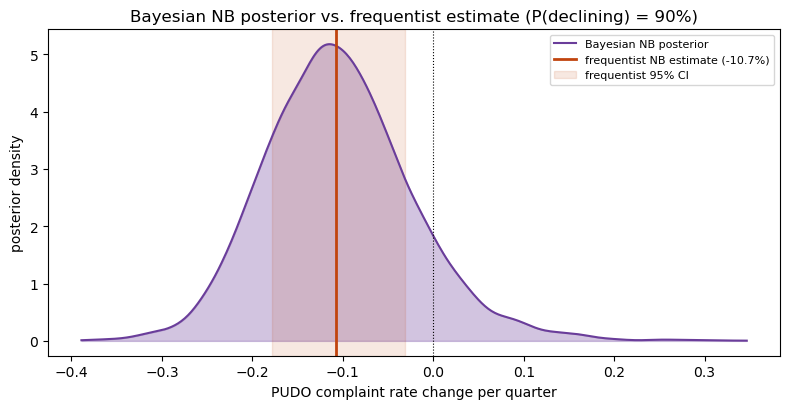

[assets] wrote tbl-bayes-nb.md
[assets] wrote bayes-trend-headline.md


In [25]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
import pymc as pm
import arviz as az

y_bayes = s["pudo_complaints"].to_numpy(dtype=float)
t_bayes = np.arange(len(s))
log_exposure = np.log(s["trips"].to_numpy(dtype=float))
pooled_rate_guess = y_bayes.sum() / s["trips"].sum()

with pm.Model() as bayes_model:
    b0 = pm.Normal("b0", mu=np.log(pooled_rate_guess), sigma=2)
    b1 = pm.Normal("b1", mu=0, sigma=1)
    alpha = pm.Exponential("alpha", 1.0)          # variance = mu + mu^2/alpha
    mu = pm.math.exp(log_exposure + b0 + b1 * t_bayes)
    pm.NegativeBinomial("y_obs", mu=mu, alpha=alpha, observed=y_bayes)
    idata = pm.sample(2000, tune=1500, chains=4, target_accept=0.95,
                       random_seed=42, progressbar=False)

diag = az.summary(idata, var_names=["b0", "b1", "alpha"], hdi_prob=0.95)
n_div = int(idata.sample_stats.diverging.sum())
print(diag.to_string())
print(f"\ndivergences: {n_div}  (0 = clean sample; max r_hat = {diag['r_hat'].max():.3f}, "
      "should be ~1.00)")

b1_samples = idata.posterior["b1"].values.flatten()
pct_change = np.exp(b1_samples) - 1
bayes_median = float(np.median(pct_change))
bayes_lo, bayes_hi = (float(x) for x in np.percentile(pct_change, [2.5, 97.5]))
p_declining = float((b1_samples < 0).mean())

print(f"\nposterior median: {bayes_median:+.1%} per quarter   "
      f"95% credible interval [{bayes_lo:+.1%}, {bayes_hi:+.1%}]")
print(f"P(rate is declining) = P(b1 < 0) = {p_declining:.1%}")
print(f"(frequentist NB point estimate: {primary['per_period']:+.1%}, "
      f"95% CI [{primary['ci'][0]:+.1%}, {primary['ci'][1]:+.1%}], p = {primary['p']:.3f})")

# posterior density vs. the frequentist point estimate + CI
kde = stats.gaussian_kde(pct_change)
xs = np.linspace(pct_change.min(), pct_change.max(), 400)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.fill_between(xs, kde(xs), color="#6a3d9a", alpha=0.3)
ax.plot(xs, kde(xs), color="#6a3d9a", lw=1.5, label="Bayesian NB posterior")
ax.axvline(0, color="k", lw=0.8, ls=":")
ax.axvline(primary["per_period"], color="#c1440e", lw=2,
           label=f"frequentist NB estimate ({primary['per_period']:+.1%})")
ax.axvspan(primary["ci"][0], primary["ci"][1], color="#c1440e", alpha=0.12,
           label="frequentist 95% CI")
ax.set_xlabel("PUDO complaint rate change per quarter")
ax.set_ylabel("posterior density")
ax.set_title(f"Bayesian NB posterior vs. frequentist estimate "
             f"(P(declining) = {p_declining:.0%})")
ax.legend(fontsize=8)
plt.tight_layout()
save_fig(fig, "fig-bayes-trend")
plt.show()

save_table(
    diag[["mean", "sd", "hdi_2.5%", "hdi_97.5%", "r_hat", "ess_bulk"]]
        .reset_index().rename(columns={"index": "parameter"}).round(3),
    "tbl-bayes-nb",
    "Bayesian Negative-Binomial trend model posterior summary "
    "(PyMC/NUTS, 4 chains x 2000 draws, 0 divergences).",
)
save_text(
    f"A Bayesian Negative-Binomial fit (weakly informative priors, PyMC/NUTS, "
    f"4 chains x 2000 draws, {n_div} divergences, max R-hat "
    f"{diag['r_hat'].max():.2f}) gives a posterior median slope of "
    f"**{bayes_median:+.1%}** per quarter (95% credible interval "
    f"[{bayes_lo:+.1%}, {bayes_hi:+.1%}]) and **P(the rate is declining) = "
    f"{p_declining:.0%}** -- consistent with, but appropriately less certain "
    f"than, the frequentist p = {primary['p']:.3f}.",
    "bayes-trend-headline",
)

In [26]:
# prior-sensitivity check: does the weakly-informative prior on the slope
# drive P(declining), or does the data? Refit at 0.25x/2x the prior width.
sens_rows = []
for sigma_b1 in (0.5, 1.0, 2.0):
    with pm.Model():
        b0_s = pm.Normal("b0", mu=np.log(pooled_rate_guess), sigma=2)
        b1_s = pm.Normal("b1", mu=0, sigma=sigma_b1)
        alpha_s = pm.Exponential("alpha", 1.0)
        mu_s = pm.math.exp(log_exposure + b0_s + b1_s * t_bayes)
        pm.NegativeBinomial("y_obs", mu=mu_s, alpha=alpha_s, observed=y_bayes)
        idata_s = pm.sample(1500, tune=1000, chains=4, target_accept=0.95,
                             random_seed=42, progressbar=False)
    b1s = idata_s.posterior["b1"].values.flatten()
    pcts = np.exp(b1s) - 1
    sens_rows.append({
        "prior sd on slope": sigma_b1,
        "posterior median %/qtr": f"{np.median(pcts):+.1%}",
        "P(declining)": f"{(b1s < 0).mean():.1%}",
    })

sens = pd.DataFrame(sens_rows)
print(sens.to_string(index=False))
print("\nBarely moves across a 4x range of prior width -> the data, not the "
      "prior, drives this result (same conclusion as the Beta-Binomial check "
      "in section 5).")

save_table(sens, "tbl-bayes-prior-sensitivity",
           "Bayesian NB posterior sensitivity to the prior width on the trend slope.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, alpha]
Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, alpha]
Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b0, b1, alpha]
Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 2 seconds.


 prior sd on slope posterior median %/qtr P(declining)
               0.5                 -11.0%        90.0%
               1.0                 -10.8%        90.6%
               2.0                 -11.1%        90.6%

Barely moves across a 4x range of prior width -> the data, not the prior, drives this result (same conclusion as the Beta-Binomial check in section 5).
[assets] wrote tbl-bayes-prior-sensitivity.md


## 4. Guardrails

- **n = 8 quarters.** Every slope is reported with a CI; none is a point estimate.
- **2024 launch ramp.** The launch-period sensitivity analysis (§3a) shows the
  full-period decline weakens and loses significance once both 2024 quarters
  are excluded. The honest reading is *"2024 was much worse; 2025–26 is
  comparatively flat,"* not necessarily a steady ongoing decline. Leave-one-out
  shows no other single period drives the result.
- **Schema break at 2024/2025.** 2024 numerators are one aggregate count per
  quarter; 2025Q1+ are summed ride-level flags. A level shift there could look
  like trend — another reason to lean on the "flat since 2025Q1" statement.
- **Overdispersion.** Poisson equidispersion is rejected (§1b), so all trend
  inference uses Negative Binomial, not the Poisson diagnostic fit.
- **Redacted series are omitted, not zeroed** — `PUDOTravelLane` has no panel.


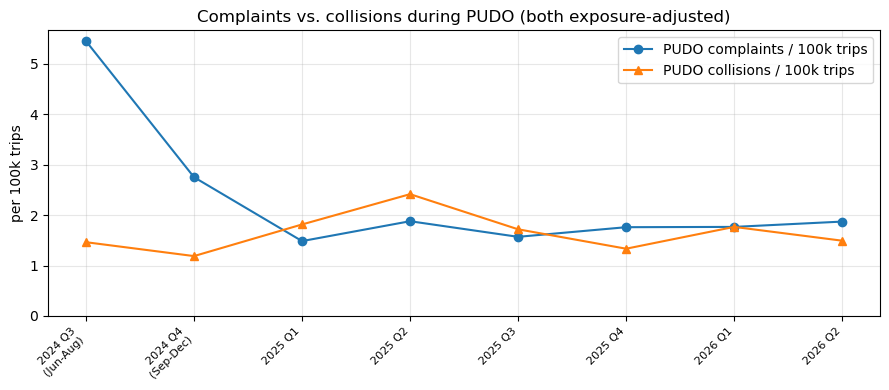

In [27]:
# supporting severity view: PUDO collisions vs complaints, both exposure-adjusted
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(s["t"], s["pudo_per_100k_trips"], marker="o", label="PUDO complaints / 100k trips")
ax.plot(s["t"], s["pudo_collisions"] / s["trips"] * 1e5, marker="^",
        label="PUDO collisions / 100k trips")
ax.set_xticks(s["t"]); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("per 100k trips"); ax.set_ylim(0)
ax.set_title("Complaints vs. collisions during PUDO (both exposure-adjusted)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Risk curve & risk-matrix placement

Two figures drive the placement:

1. **Risk curve** — the PUDO event rate (per 100k trips) at each step up in
   consequence severity: any complaint → collision → collision involving a
   pedestrian/cyclist → severe injury / fatality. The rate collapses ~30–100×
   per step; nothing severe or fatal was observed at the PUDO level over the
   whole window. This sets the **Impact** axis.
2. **Risk matrix** — a 5×5 Impact × Probability heat-map (Very low → Extreme),
   with the PUDO hazard placed from the data.

**Probability basis** (`PROB_BASIS`, toggle and re-run):
- `per_period` — P(≥1 PUDO complaint in a reporting quarter). ≈ 1.0 → *Almost
  certain*. This is the standard risk-register reading and the default.
- `per_trip` — the per-trip probability itself (~1 in 51,000). Maps to a middle
  band; useful for comparing hazards, misleading as a "will it happen" answer.
- `bayesian` — Beta(0.5, 0.5) prior + Binomial likelihood; the posterior rate is
  essentially the empirical one (417 events is a lot of data), and the
  posterior-predictive P(≥1 next quarter) ≈ 1.0 → *Almost certain*.

*Write-up caveats:* complaints are self-reported by Waymo to its regulator
(measures *reported* problems; reporting propensity may drift); Waymo entered new
cities during the window (rate change can reflect market mix); the 2024 periods
are not calendar quarters and use a different source table; redaction blocks any
within-quarter timing/location analysis and the severity of individual PUDO
collisions is not published (the "severe/fatal" rung is a 0-observed upper bound).

[assets] wrote fig-risk-curve.png


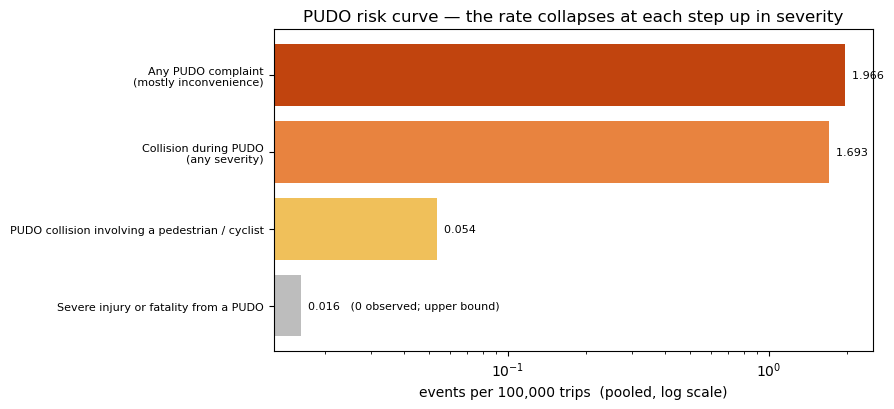

                                    consequence   impact_tier  per_100k_trips  observed
      Any PUDO complaint (mostly inconvenience) Insignificant           1.966      True
           Collision during PUDO (any severity)         Minor           1.693      True
PUDO collision involving a pedestrian / cyclist   Significant           0.054      True
          Severe injury or fatality from a PUDO        Severe           0.016     False

VRU-involved PUDO collisions: 10 over the window (0 pedestrian); severe/fatal: 0 observed.
Tiers clearing 0.1/100k trips: ['Insignificant', 'Minor']  ->  IMPACT = Minor


In [28]:
# --- 5a. Risk curve: PUDO event rate vs. consequence severity -----------------
# All rates per 100,000 trips, pooled. Collision-severity detail lives only in
# the 2025Q1+ ride-level microdata, so rungs 2-4 use those periods; rung 1 (any
# complaint) uses the full window.
trips_all   = float(s["trips"].sum())
trips_micro = float(s.loc[s["period_id"] >= "2025Q1", "trips"].sum())
k_all       = int(s["pudo_complaints"].sum())

vru_cols = ["CollisionPUDOPedestrian", "CollisionPUDOBicycleScooter", "CollisionPUDOMotorcycles"]
n_coll = int(complaints.select(pl.col("CollisionPUDOAny").sum()).item())
n_vru  = int(complaints.select(pl.any_horizontal([pl.col(c) for c in vru_cols]).sum()).item())
n_ped  = int(complaints.select(pl.col("CollisionPUDOPedestrian").sum()).item())

curve = pd.DataFrame({
    "consequence": ["Any PUDO complaint (mostly inconvenience)",
                    "Collision during PUDO (any severity)",
                    "PUDO collision involving a pedestrian / cyclist",
                    "Severe injury or fatality from a PUDO"],
    "impact_tier": ["Insignificant", "Minor", "Significant", "Severe"],
    "per_100k_trips": [k_all / trips_all * 1e5,
                       n_coll / trips_micro * 1e5,
                       n_vru / trips_micro * 1e5,
                       3 / trips_micro * 1e5],          # 0 observed -> rule-of-three upper bound
    "observed": [True, True, n_vru > 0, False],
})

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(range(len(curve)), curve["per_100k_trips"],
        color=["#c1440e", "#e8833f", "#f0c05a", "#bdbdbd"])
for i, row in curve.iterrows():
    tag = f"  {row.per_100k_trips:.3f}" + ("" if row.observed else "   (0 observed; upper bound)")
    ax.text(row.per_100k_trips, i, tag, va="center", fontsize=8)
ax.set_yticks(range(len(curve)))
ax.set_yticklabels([c.replace(" (", "\n(") for c in curve["consequence"]], fontsize=8)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("events per 100,000 trips  (pooled, log scale)")
ax.set_title("PUDO risk curve — the rate collapses at each step up in severity")
plt.tight_layout()
save_fig(fig, "fig-risk-curve")
plt.show()

# Impact band = worst consequence tier that is *observed* and frequent enough to
# characterise the hazard (default >= 0.10 per 100k trips, ~1 per million trips).
IMPACT_MIN_RATE = 0.10
clears = curve[(curve["per_100k_trips"] >= IMPACT_MIN_RATE) & curve["observed"]]
IMPACT_BAND = clears["impact_tier"].iloc[-1] if len(clears) else "Insignificant"

print(curve.assign(per_100k_trips=curve["per_100k_trips"].round(3)).to_string(index=False))
print(f"\nVRU-involved PUDO collisions: {n_vru} over the window "
      f"({n_ped} pedestrian); severe/fatal: 0 observed.")
print(f"Tiers clearing {IMPACT_MIN_RATE}/100k trips: {list(clears['impact_tier'])}"
      f"  ->  IMPACT = {IMPACT_BAND}")

prob basis    probability impact risk level
per_period Almost certain  Minor     Medium
  per_trip       Moderate  Minor        Low
  bayesian Almost certain  Minor     Medium

[assets] wrote fig-risk-matrix.png


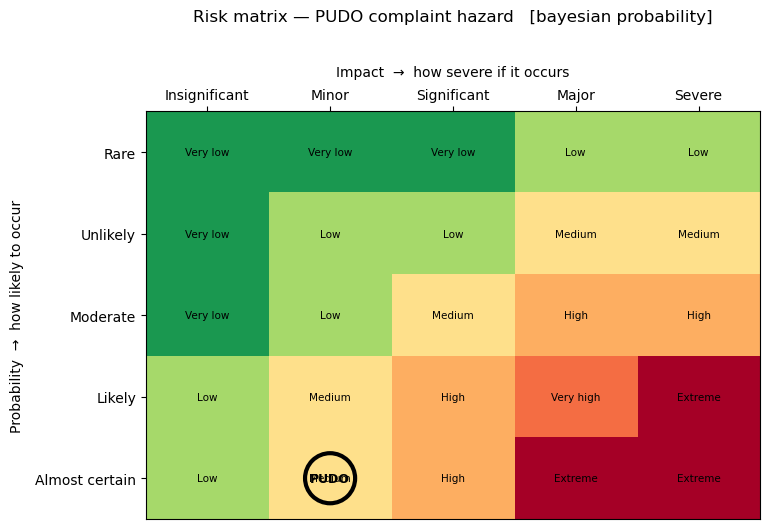

PROBABILITY : Almost certain  (posterior rate 1.97/100k trips (95% CrI 1.78-2.16); predictive P(>=1 next quarter) = 1.0000)
IMPACT      : Minor           (worst consequence tier clearing 0.1/100k trips — see risk curve)
RISK LEVEL  : Medium   (score 10/25)
[assets] wrote tbl-risk-basis.md
[assets] wrote risk-headline.md


In [29]:
# --- 5b. Risk matrix (5x5): place the PUDO hazard from the data ----------------
PROB_BASIS = "bayesian"          # "per_period" | "per_trip" | "bayesian"

IMPACT_LABELS = ["Insignificant", "Minor", "Significant", "Major", "Severe"]
PROB_LABELS   = ["Rare", "Unlikely", "Moderate", "Likely", "Almost certain"]
LEVELS        = ["Very low", "Low", "Medium", "High", "Very high", "Extreme"]

def score_to_level(score):                         # (prob 1-5) x (impact 1-5) = 1..25
    return int(np.searchsorted([3, 6, 10, 15, 19], score))   # <=3 VL .. else Extreme

grid = np.array([[score_to_level((r + 1) * (c + 1)) for c in range(5)] for r in range(5)])

mean_q  = float(s["pudo_complaints"].mean())        # ~52 PUDO complaints / quarter
p_trip  = k_all / trips_all
next_q  = float(s["trips"].iloc[-1])                # size of a typical future quarter

def probability(basis):
    """-> (p, band_index, note) for one probability basis."""
    if basis == "per_period":
        p = 1 - np.exp(-mean_q)
        idx = int(np.searchsorted([0.05, 0.25, 0.50, 0.90], p))
        note = f"P(>=1 PUDO complaint in a quarter) = {p:.4f}"
    elif basis == "per_trip":
        p = p_trip
        idx = int(np.searchsorted([1e-6, 1e-5, 1e-4, 1e-3], p))
        note = f"per-trip probability {p:.2e}  (~1 per {1 / p:,.0f} trips)"
    elif basis == "bayesian":
        a, b = 0.5 + k_all, 0.5 + trips_all - k_all
        rate = a / (a + b)
        lo, hi = stats.beta.ppf([0.025, 0.975], a, b) * 1e5
        p = 1 - np.exp(-rate * next_q)              # posterior-predictive P(>=1 next quarter)
        idx = int(np.searchsorted([0.05, 0.25, 0.50, 0.90], p))
        note = (f"posterior rate {rate * 1e5:.2f}/100k trips (95% CrI {lo:.2f}-{hi:.2f}); "
                f"predictive P(>=1 next quarter) = {p:.4f}")
    return p, min(idx, 4), note

impact_idx = IMPACT_LABELS.index(IMPACT_BAND)
_p, prob_idx, prob_note = probability(PROB_BASIS)
RISK_PROB, RISK_IMPACT = PROB_LABELS[prob_idx], IMPACT_LABELS[impact_idx]
RISK_LEVEL = LEVELS[score_to_level((prob_idx + 1) * (impact_idx + 1))]

# how the placement moves with the probability basis
comp = pd.DataFrame(
    [[b, PROB_LABELS[probability(b)[1]], IMPACT_BAND,
      LEVELS[score_to_level((probability(b)[1] + 1) * (impact_idx + 1))]]
     for b in ("per_period", "per_trip", "bayesian")],
    columns=["prob basis", "probability", "impact", "risk level"],
)
print(comp.to_string(index=False))
print()

from matplotlib.colors import ListedColormap
CMAP = ListedColormap(["#1a9850", "#a6d96a", "#fee08b", "#fdae61", "#f46d43", "#a50026"])
fig, ax = plt.subplots(figsize=(7.8, 5.4))
ax.imshow(grid, cmap=CMAP, vmin=0, vmax=5, aspect="auto")
for r in range(5):
    for c in range(5):
        ax.text(c, r, LEVELS[grid[r, c]], ha="center", va="center", fontsize=7.5)
ax.set_xticks(range(5), IMPACT_LABELS)
ax.set_yticks(range(5), PROB_LABELS)
ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
ax.set_xlabel("Impact  →  how severe if it occurs", labelpad=8)
ax.set_ylabel("Probability  →  how likely to occur", labelpad=8)
ax.set_title(f"Risk matrix — PUDO complaint hazard   [{PROB_BASIS} probability]", pad=32)
ax.scatter(impact_idx, prob_idx, s=1300, facecolors="none", edgecolors="black", linewidths=3, zorder=5)
ax.annotate("PUDO", (impact_idx, prob_idx), ha="center", va="center",
            fontsize=9, fontweight="bold", zorder=6)
plt.tight_layout()
save_fig(fig, "fig-risk-matrix")
plt.show()

print(f"PROBABILITY : {RISK_PROB:<15s} ({prob_note})")
print(f"IMPACT      : {RISK_IMPACT:<15s} (worst consequence tier clearing "
      f"{IMPACT_MIN_RATE}/100k trips — see risk curve)")
print(f"RISK LEVEL  : {RISK_LEVEL}   (score {(prob_idx + 1) * (impact_idx + 1)}/25)")

save_table(comp, "tbl-risk-basis",
           "PUDO risk-matrix placement under three probability bases (impact held fixed).")
save_text(
    f"Probability: **{RISK_PROB}** ({prob_note}). Impact: **{RISK_IMPACT}** (the worst "
    f"consequence tier clearing {IMPACT_MIN_RATE}/100k trips in the risk curve above). "
    f"Combined risk level: **{RISK_LEVEL}**.",
    "risk-headline",
)

In [30]:
# ---- plain-English summary ---------------------------------------------------
p = primary
pk, pt = int(s["pudo_complaints"].sum()), float(s["trips"].sum())
pooled_trip = pk / pt * 1e5
plo, phi = poisson_ci(pk, pt)
direction = "FALLING" if p["per_period"] < 0 else "RISING"
flat_lo, flat_hi = s["pudo_per_100k_trips"].iloc[2:].min(), s["pudo_per_100k_trips"].iloc[2:].max()
vmt_result = results["VMT total (cross-check)"]

print(f"""PLAIN-ENGLISH SUMMARY  —  PUDO complaint risk, Waymo driverless, 2024Q3–2026Q2
============================================================================
BASELINE RATE (descriptive, exact Poisson CI on the pooled count)
  {pooled_trip:.2f} PUDO complaints per 100,000 trips  (exact Poisson 95% CI {plo:.2f}–{phi:.2f})
  from {pk} complaints over {pt/1e6:.1f}M trips.
  PUDO is ~{mix['pudo_share_of_complaints'].mean():.0%} of all reported complaint categories.
  (This exact-Poisson interval describes uncertainty around the pooled COUNT;
  it is not the trend model's uncertainty -- see below.)

PRIMARY TREND MODEL: Negative-Binomial regression (trips exposure)
  {direction}. beta_t = {p['beta']:+.3f} (SE {p['se']:.3f}), IRR = exp(beta_t) = {p['irr']:.3f}
  -> {p['per_period']:+.1%} per quarter (95% CI {p['ci'][0]:+.1%} to {p['ci'][1]:+.1%}, p = {p['p']:.3f});
  total {p['total']:+.0%} over the window.
  Same direction under the VMT-total cross-check ({vmt_result['per_period']:+.1%}/qtr,
  p = {vmt_result['p']:.3f}) and Mann-Kendall's tau is negative under both
  (a distribution-free robustness check, not the primary model).
  Poisson was fit first as a diagnostic baseline but is overdispersed
  (Pearson chi2/df = {p['dispersion']:.1f}), so it is NOT used for inference --
  Negative Binomial is the primary trend model throughout.

LAUNCH-PERIOD SENSITIVITY (§3a): is the decline a 2024 ramp effect?
  Post-ramp window (2025Q1-2026Q2, n={window_post['n']}): {window_post['per_period']:+.1%}/qtr
  (95% CI {window_post['ci'][0]:+.1%} to {window_post['ci'][1]:+.1%}, p = {window_post['p']:.3f})
  vs. {p['per_period']:+.1%}/qtr (p = {p['p']:.3f}) over the full window.
  {interpretation}

BAYESIAN CHECK (PyMC NUTS, weakly informative priors, prior-insensitive)
  Posterior median {bayes_median:+.1%}/qtr (95% credible interval [{bayes_lo:+.1%}, {bayes_hi:+.1%}]).
  P(the rate is declining) = {p_declining:.0%} -- appropriately less confident than a
  large-sample p-value alone would suggest, since it propagates uncertainty in
  both the regression and dispersion parameters given n = 8.

CONFIDENCE: MODERATE, with one big caveat.
  n = 8 quarters. Since 2025Q1 the rate has been essentially flat
  ({flat_lo:.2f}–{flat_hi:.2f} per 100k trips); see the launch-period sensitivity
  analysis above for how much of the full-period decline that launch ramp explains.

RISK-MATRIX PLACEMENT ({PROB_BASIS} probability)
  {RISK_PROB} probability  ×  {RISK_IMPACT} impact  =  {RISK_LEVEL}.
  Impact is low because the risk curve collapses ~30–100x from "complaint" to
  "collision" to "pedestrian/cyclist involved", with 0 severe/fatal PUDO events
  observed. (per_trip probability drops the placement one band; see cell 5b.)

BOTTOM LINE
  After controlling for exposure, PUDO complaints are NOT rising — the primary NB
  model shows a decline concentrated in the 2024 launch ramp, with 2025-26 rates
  comparatively flat; the Bayesian fit says "very likely, not certain."
  Risk: {RISK_LEVEL} ({RISK_PROB} × {RISK_IMPACT}) — monitor-and-mitigate (designated
  PUDO zones, curb-space management); direction arrow flat-to-down.
""")


PLAIN-ENGLISH SUMMARY  —  PUDO complaint risk, Waymo driverless, 2024Q3–2026Q2
BASELINE RATE (descriptive, exact Poisson CI on the pooled count)
  1.97 PUDO complaints per 100,000 trips  (exact Poisson 95% CI 1.78–2.16)
  from 417 complaints over 21.2M trips.
  PUDO is ~13% of all reported complaint categories.
  (This exact-Poisson interval describes uncertainty around the pooled COUNT;
  it is not the trend model's uncertainty -- see below.)

PRIMARY TREND MODEL: Negative-Binomial regression (trips exposure)
  FALLING. beta_t = -0.114 (SE 0.042), IRR = exp(beta_t) = 0.893
  -> -10.7% per quarter (95% CI -17.8% to -3.1%, p = 0.007);
  total -55% over the window.
  Same direction under the VMT-total cross-check (-12.7%/qtr,
  p = 0.001) and Mann-Kendall's tau is negative under both
  (a distribution-free robustness check, not the primary model).
  Poisson was fit first as a diagnostic baseline but is overdispersed
  (Pearson chi2/df = 5.2), so it is NOT used for inference --
  Negative

In [31]:
# CSV snapshots for sharing / the write-up. Defaults to the repo root; override
# with PUDO_EXPORT_DIR.
EXPORT = Path(os.environ.get("PUDO_EXPORT_DIR", Path("..") / "..")).resolve()
EXPORT.mkdir(parents=True, exist_ok=True)

final_summary = summary.select("period_label", "trips", "pudo_complaints")

# summary.write_csv(EXPORT / "pudo_summary.csv")
# final_summary.write_csv(EXPORT / "final_pudo_summary.csv")
# monthly.write_csv(EXPORT / "monthly_activity.csv")
# trend_table.to_csv(EXPORT / "pudo_trend_by_denominator.csv", index=False)
# complaints.sample(n=10_000, seed=42).write_csv(EXPORT / "complaints.csv")
# print("wrote pudo_summary.csv, final_pudo_summary.csv, monthly_activity.csv, "
#       "pudo_trend_by_denominator.csv, complaints.csv to", EXPORT)
# final_summary